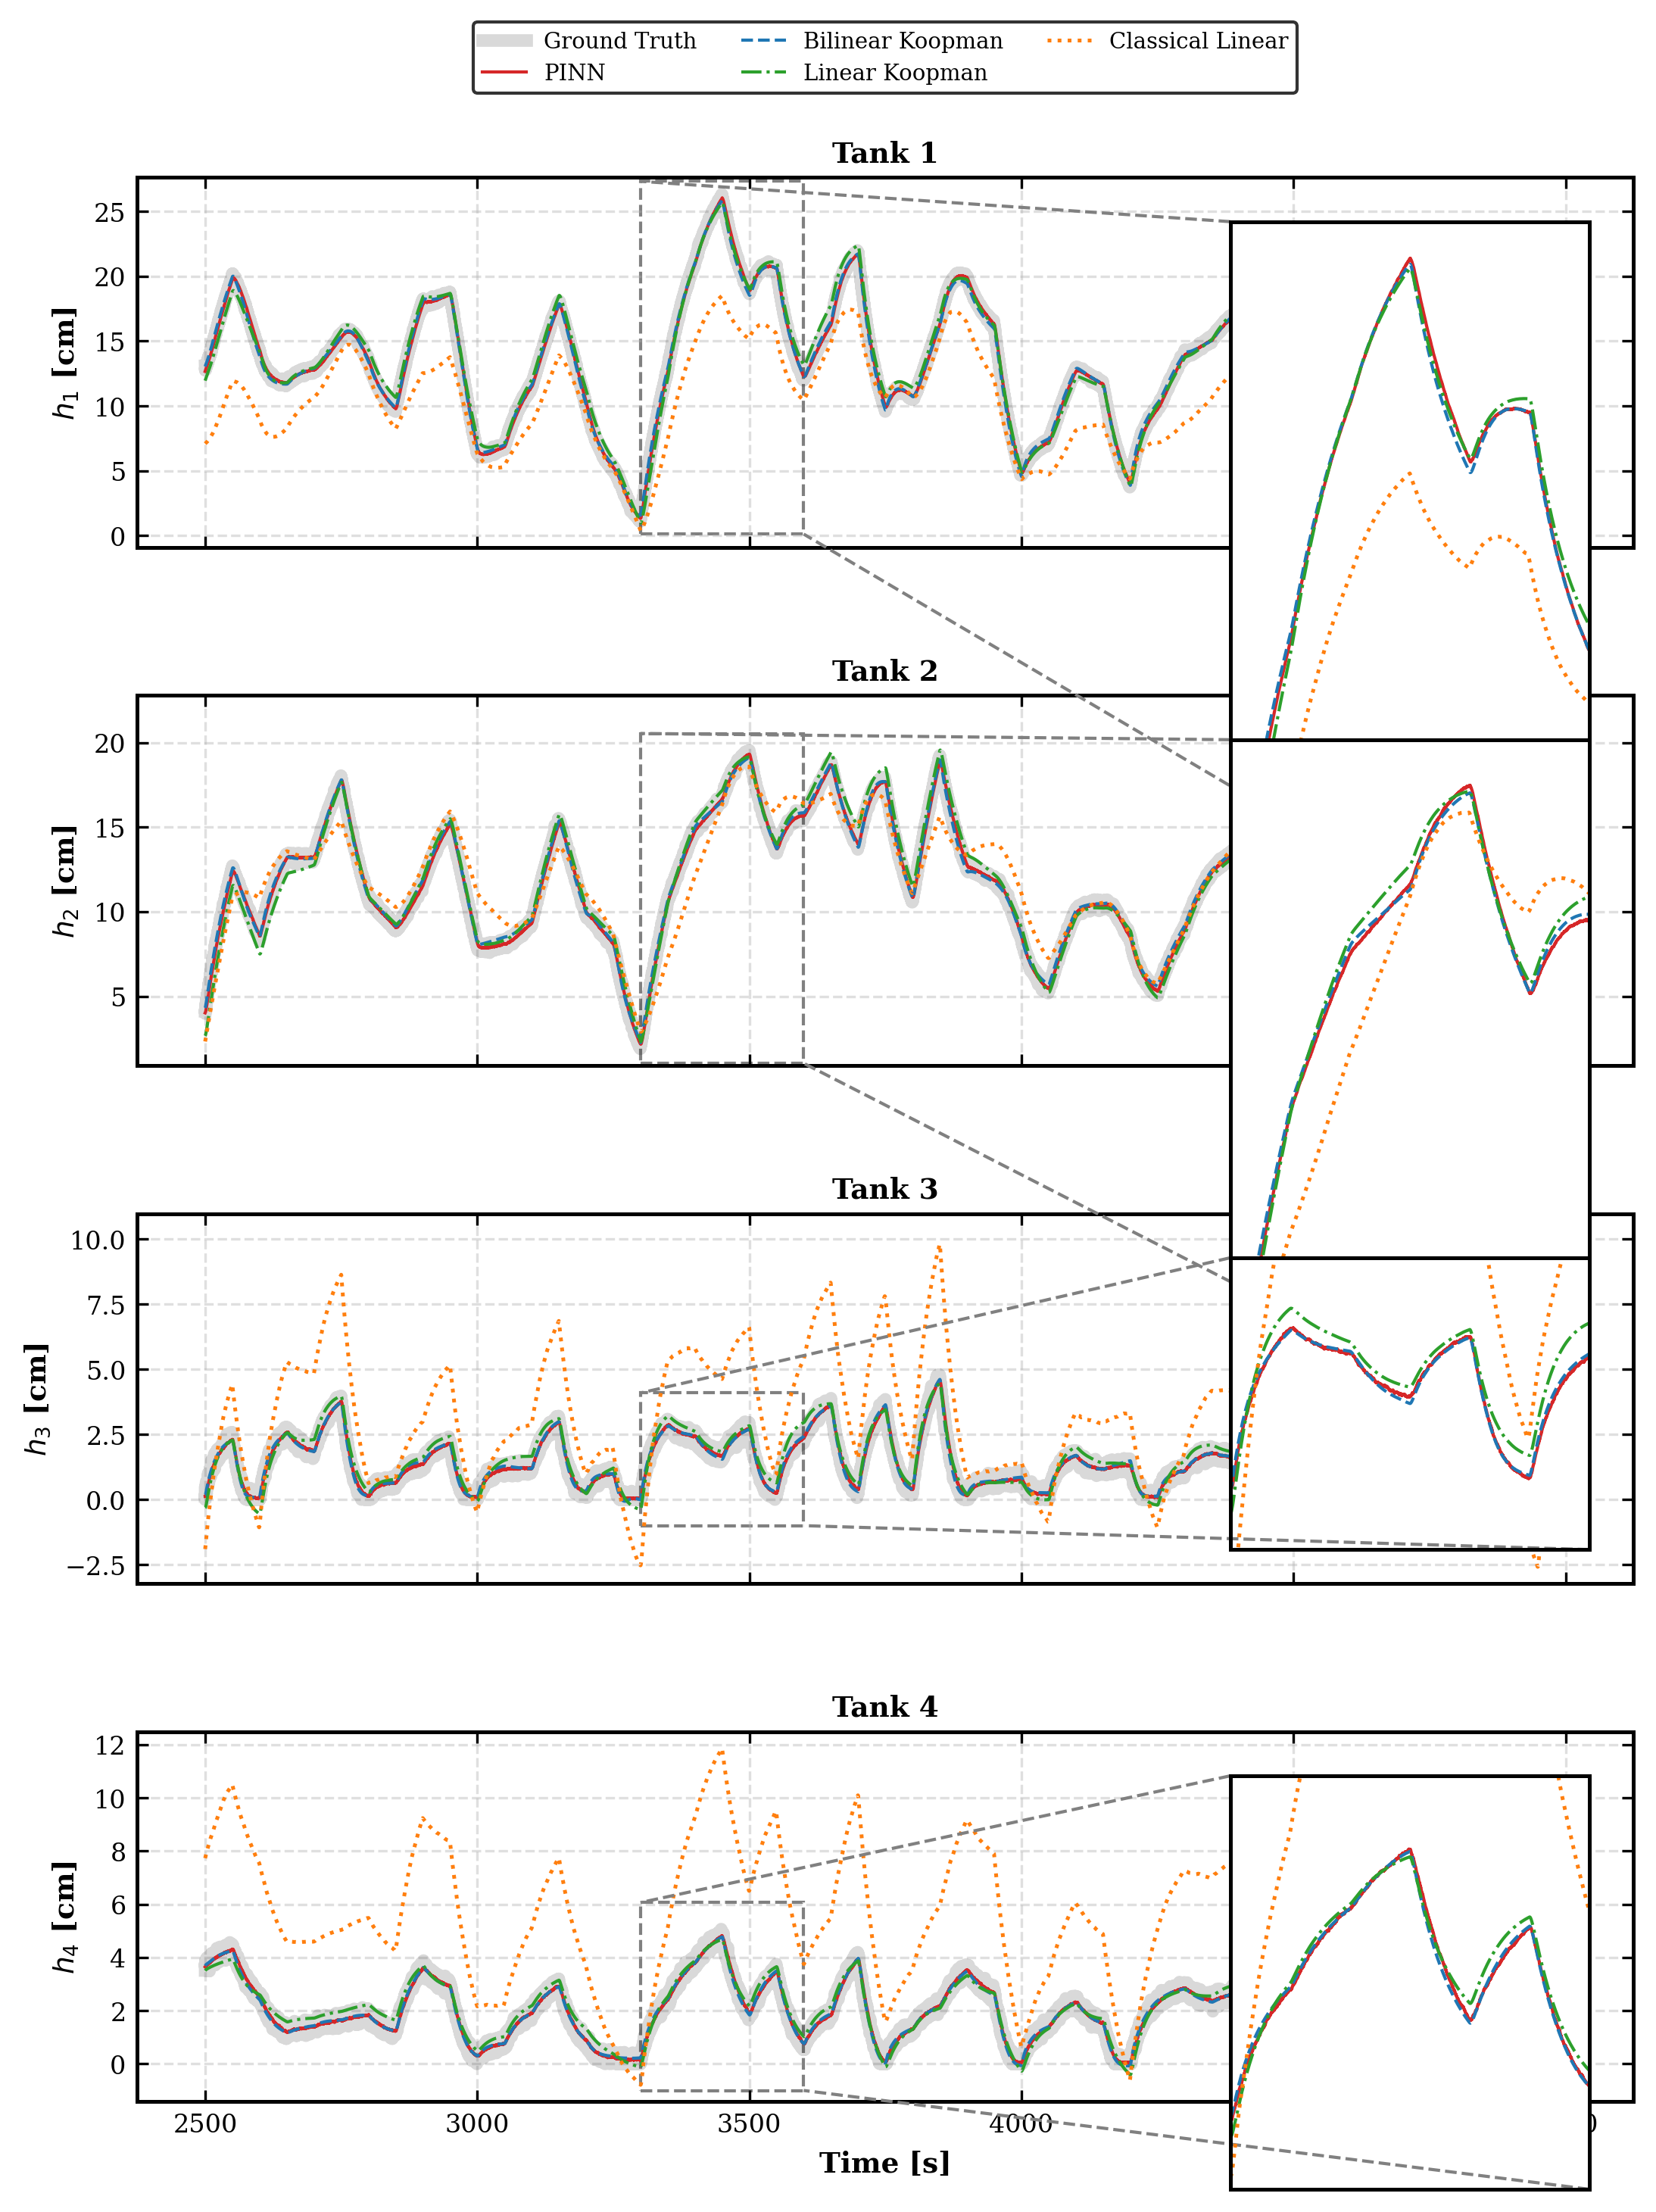

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

# 1. CARGA DE DATOS (Mantenemos la carga centralizada)
df_real = pd.read_csv('simulacion_real.csv')
df_p_inf = pd.read_csv('comparacion_pinn_tanques_inferiores.csv')
df_kb_inf = pd.read_csv('comparacion_koopman_bilineal_tanques_inferiores.csv')
df_kl_inf = pd.read_csv('comparacion_koopman_lineal_tanques_inferiores.csv')
df_lin_inf = pd.read_csv('comparacion_linealizacion_tanques_inferiores.csv')

df_p_sup = pd.read_csv('comparacion_pinn_tanques_superiores.csv')
df_kb_sup = pd.read_csv('comparacion_koopman_bilineal_tanques_superiores.csv')
df_kl_sup = pd.read_csv('comparacion_koopman_lineal_tanques_superiores.csv')
df_lin_sup = pd.read_csv('comparacion_linealizacion_tanques_superiores.csv')

# 2. CONFIGURACIÓN ESTILO IEEE
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman"],
    "font.size": 9,
    "axes.linewidth": 1.2,
})

fig, axs = plt.subplots(4, 1, figsize=(8.5, 11), sharex=True, dpi=300)
t_start, t_end = 2500, 5000

# Parámetros del Zoom (ajusta t_zoom_start/end según lo que quieras resaltar)
t_zoom_start, t_zoom_end = 3300, 3600

config = [
    (0, 'Tank 1', '$h_1$ [cm]', [df_p_inf, df_kb_inf, df_kl_inf, df_lin_inf], 'h1'),
    (1, 'Tank 2', '$h_2$ [cm]', [df_p_inf, df_kb_inf, df_kl_inf, df_lin_inf], 'h2'),
    (2, 'Tank 3', '$h_3$ [cm]', [df_p_sup, df_kb_sup, df_kl_sup, df_lin_sup], 'h3'),
    (3, 'Tank 4', '$h_4$ [cm]', [df_p_sup, df_kb_sup, df_kl_sup, df_lin_sup], 'h4')
]

model_styles = [
    {'label': 'PINN', 'color': '#D62728', 'ls': '-', 'lw': 1.0, 'sufijo': 'PINN'},
    {'label': 'Bilinear Koopman', 'color': '#1F77B4', 'ls': '--', 'lw': 1.0, 'sufijo': 'Koopman'},
    {'label': 'Linear Koopman', 'color': '#2CA02C', 'ls': '-.', 'lw': 1.0, 'sufijo': 'Koopman_Lin'},
    {'label': 'Classical Linear', 'color': '#FF7F0E', 'ls': ':', 'lw': 1.2, 'sufijo': 'Classical'}
]

for i, title, ylabel, dfs, base_col in config:
    ax = axs[i]

    # --- Gráfica Principal ---
    m_real = (df_real['Tiempo [s]'] >= t_start) & (df_real['Tiempo [s]'] <= t_end)
    ax.plot(df_real.loc[m_real, 'Tiempo [s]'], df_real.loc[m_real, f'{base_col}_Real [cm]'],
            color='black', alpha=0.15, linewidth=4, label='Ground Truth')

    # Crear el eje del Zoom (inset)
    # zoom=2.5 significa 250% de aumento, loc=1 es arriba a la derecha
    ax_ins = zoomed_inset_axes(ax, zoom=2.2, loc='upper right', borderpad=2)

    for df, style in zip(dfs, model_styles):
        mask = (df['Tiempo [s]'] >= t_start) & (df['Tiempo [s]'] <= t_end)
        col_name = [c for c in df.columns if base_col in c and style['sufijo'] in c][0]

        # Plot en el eje principal
        ax.plot(df.loc[mask, 'Tiempo [s]'], df.loc[mask, col_name],
                color=style['color'], linestyle=style['ls'], linewidth=style['lw'], label=style['label'])

        # Plot en el Zoom (repetimos la lógica para las mismas líneas)
        mask_zoom = (df['Tiempo [s]'] >= t_zoom_start) & (df['Tiempo [s]'] <= t_zoom_end)
        ax_ins.plot(df.loc[mask_zoom, 'Tiempo [s]'], df.loc[mask_zoom, col_name],
                    color=style['color'], linestyle=style['ls'], linewidth=style['lw'])

    # Configurar límites y apariencia del Zoom
    ax_ins.set_xlim(t_zoom_start, t_zoom_end)
    # Ajuste automático del eje Y en el zoom basado en el Ground Truth
    y_vals = df_real.loc[(df_real['Tiempo [s]'] >= t_zoom_start) & (df_real['Tiempo [s]'] <= t_zoom_end), f'{base_col}_Real [cm]']
    ax_ins.set_ylim(y_vals.min() - 1, y_vals.max() + 1)

    ax_ins.set_xticks([]) # Quitar números del eje X en el zoom para no saturar
    ax_ins.set_yticks([]) # Quitar números del eje Y en el zoom
    ax_ins.grid(True, linestyle='--', alpha=0.3)

    # Dibujar las líneas que conectan el zoom con la gráfica principal
    mark_inset(ax, ax_ins, loc1=2, loc2=4, fc="none", ec="0.5", ls='--')

    # Formato eje principal
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontsize=9, fontweight='bold', pad=5)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(direction='in', top=True, right=True)

axs[3].set_xlabel('Time [s]', fontweight='bold')
axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.45), ncol=3, frameon=True, edgecolor='black')

plt.subplots_adjust(hspace=0.4)
plt.savefig('comparativa_ieee_zoom.png', bbox_inches='tight')
plt.show()

In [8]:
import pandas as pd
import numpy as np

def calculate_metrics(real, pred):
    # --- Lógica de Alineación (Solución al ValueError) ---
    # Si los tamaños no coinciden, recortamos al tamaño del más pequeño
    min_len = min(len(real), len(pred))
    real = real[:min_len]
    pred = pred[:min_len]

    mse = np.mean((real - pred)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(real - pred))
    sse = np.sum((real - pred)**2)
    vaf = max(0, (1 - np.var(real - pred) / np.var(real))) * 100
    rango = np.max(real) - np.min(real)
    nrmse = (rmse / rango) * 100 if rango != 0 else 0
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'SSE': sse, 'VAF': vaf, 'NRMSE': nrmse}

# 1. CARGA DE DATOS
df_real = pd.read_csv('simulacion_real.csv')

archivos_modelos = {
    'PINN': {
        'inf': pd.read_csv('comparacion_pinn_tanques_inferiores.csv'),
        'sup': pd.read_csv('comparacion_pinn_tanques_superiores.csv'),
        'suffix': 'PINN'
    },
    'Bilinear Koopman': {
        'inf': pd.read_csv('comparacion_koopman_bilineal_tanques_inferiores.csv'),
        'sup': pd.read_csv('comparacion_koopman_bilineal_tanques_superiores.csv'),
        'suffix': 'Koopman'
    },
    'Linear Koopman': {
        'inf': pd.read_csv('comparacion_koopman_lineal_tanques_inferiores.csv'),
        'sup': pd.read_csv('comparacion_koopman_lineal_tanques_superiores.csv'),
        'suffix': 'Koopman_Lin'
    },
    'Classical Linear': {
        'inf': pd.read_csv('comparacion_linealizacion_tanques_inferiores.csv'),
        'sup': pd.read_csv('comparacion_linealizacion_tanques_superiores.csv'),
        'suffix': 'Classical'
    }
}

final_results = {}

for model_name, cfg in archivos_modelos.items():
    suffix = cfg['suffix']
    df_i = cfg['inf']
    df_s = cfg['sup']

    tanks_metrics = {}
    all_real_list = []
    all_pred_list = []

    for tank_idx in range(1, 5):
        base_col = f'h{tank_idx}'
        df_source = df_i if tank_idx <= 2 else df_s

        # Extraer valores asegurando que sean arrays de numpy
        real = df_real[f'{base_col}_Real [cm]'].values

        try:
            col_pred = [c for c in df_source.columns if base_col in c and suffix in c][0]
            pred = df_source[col_pred].values

            # La función ahora maneja internamente la diferencia de (100001,) vs (100000,)
            m = calculate_metrics(real, pred)
            tanks_metrics[base_col] = m

            # Para las métricas globales, también recortamos antes de concatenar
            min_l = min(len(real), len(pred))
            all_real_list.append(real[:min_l])
            all_pred_list.append(pred[:min_l])

        except IndexError:
            continue

    if all_real_list:
        all_real = np.concatenate(all_real_list)
        all_pred = np.concatenate(all_pred_list)
        final_results[model_name] = {
            'Global': calculate_metrics(all_real, all_pred),
            'Tanks': tanks_metrics
        }

# 3. IMPRESIÓN DE RESULTADOS
for model, data in final_results.items():
    print(f"\n{'='*65}")
    print(f" 📊 REPORTE DE DESEMPEÑO: {model.upper()}")
    print(f"{'='*65}")
    g = data['Global']
    print(f"🌎 GLOBAL: RMSE: {g['RMSE']:.4f} cm | VAF: {g['VAF']:.2f} % | NRMSE: {g['NRMSE']:.2f} %")
    print("-" * 45)
    for t_id, m in data['Tanks'].items():
        print(f"  {t_id.upper():<4} -> RMSE: {m['RMSE']:.4f} cm | VAF: {m['VAF']:.2f}%")


 📊 REPORTE DE DESEMPEÑO: PINN
🌎 GLOBAL: RMSE: 0.1543 cm | VAF: 99.95 % | NRMSE: 0.55 %
---------------------------------------------
  H1   -> RMSE: 0.1996 cm | VAF: 99.86%
  H2   -> RMSE: 0.1714 cm | VAF: 99.84%
  H3   -> RMSE: 0.1190 cm | VAF: 99.12%
  H4   -> RMSE: 0.1090 cm | VAF: 99.09%

 📊 REPORTE DE DESEMPEÑO: BILINEAR KOOPMAN
🌎 GLOBAL: RMSE: 0.1578 cm | VAF: 99.94 % | NRMSE: 0.57 %
---------------------------------------------
  H1   -> RMSE: 0.1993 cm | VAF: 99.86%
  H2   -> RMSE: 0.1871 cm | VAF: 99.81%
  H3   -> RMSE: 0.1160 cm | VAF: 99.16%
  H4   -> RMSE: 0.1068 cm | VAF: 99.12%

 📊 REPORTE DE DESEMPEÑO: LINEAR KOOPMAN
🌎 GLOBAL: RMSE: 0.4772 cm | VAF: 99.49 % | NRMSE: 1.71 %
---------------------------------------------
  H1   -> RMSE: 0.7129 cm | VAF: 98.23%
  H2   -> RMSE: 0.4735 cm | VAF: 98.83%
  H3   -> RMSE: 0.3366 cm | VAF: 93.01%
  H4   -> RMSE: 0.2555 cm | VAF: 95.05%

 📊 REPORTE DE DESEMPEÑO: CLASSICAL LINEAR
🌎 GLOBAL: RMSE: 3.1293 cm | VAF: 78.91 % | NRMSE: 11.

In [15]:
import pandas as pd
import numpy as np

def calculate_metrics(real, ref):
    """Calcula el conjunto completo de métricas de desempeño"""
    error = real - ref
    mse = np.mean(error**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(error))
    sse = np.sum(error**2)

    # VAF: Variance After Filtering
    vaf = max(0, (1 - np.var(error) / np.var(ref))) * 100

    # NRMSE normalizado por el rango de la referencia
    rango = np.max(ref) - np.min(ref)
    nrmse = (rmse / rango) * 100 if rango != 0 else 0

    return {'RMSE': rmse, 'MAE': mae, 'VAF': vaf, 'NRMSE': nrmse, 'SSE': sse, 'MSE': mse}

# 1. CARGA DE DATOS DE LAZO CERRADO
df_bilinear = pd.read_csv('control_lazo_cerrado_bilinear_sinusoidal.csv')
df_pinn = pd.read_csv('control_lazo_cerrado_PINN_sinusoidal.csv')

config_modelos = {
    'NMPC Bilinear-Koopman': df_bilinear,
    'NMPC PINN': df_pinn
}

final_results = {}

for model_name, df in config_modelos.items():
    tanks = {}
    # Solo calculamos métricas para los tanques con referencia real (h1 y h2)
    for i in range(1, 3):
        h_id = f'h{i}'
        real = df[f'{h_id}_Real [cm]']
        ref = df[f'{h_id}_Ref [cm]']
        tanks[h_id] = calculate_metrics(real, ref)

    # Métricas Globales: Solo incluimos h1 y h2 (las 4 trayectorias controladas)
    all_real = np.concatenate([df['h1_Real [cm]'], df['h2_Real [cm]']])
    all_ref = np.concatenate([df['h1_Ref [cm]'], df['h2_Ref [cm]']])

    global_m = calculate_metrics(all_real, all_ref)
    final_results[model_name] = {'Global': global_m, 'Tanks': tanks}

# 2. IMPRESIÓN FORMATEADA PARA ARTÍCULO
for model, data in final_results.items():
    print(f"\n{'='*65}")
    print(f" ANÁLISIS DE DESEMPEÑO: {model}")
    print(f"{'='*65}")

    # --- Métricas por Tanque (Solo h1 y h2) ---
    print(f"{'Tanque':<8} | {'RMSE (cm)':<12} | {'MAE (cm)':<12} | {'VAF (%)':<10}")
    print(f"{'-'*50}")
    for t_id, m in data['Tanks'].items():
        print(f"{t_id.upper():<8} | {m['RMSE']:<12.4f} | {m['MAE']:<12.4f} | {m['VAF']:<10.2f}")

    print(f"{'-'*65}")

    # --- Métricas Globales (Basadas solo en el control de h1 y h2) ---
    g = data['Global']
    print(f"📊 RESUMEN GLOBAL DEL SISTEMA (Control h1, h2):")
    print(f"  > RMSE   : {g['RMSE']:.4f} cm")
    print(f"  > MAE    : {g['MAE']:.4f} cm")
    print(f"  > VAF    : {g['VAF']:.2f} %")
    print(f"  > MSE    : {g['MSE']:.4f} cm²")
    print(f"  > SSE    : {g['SSE']:.2f} cm²")
    print(f"  > NRMSE  : {g['NRMSE']:.2f} %")
    print(f"{'='*65}\n")


 ANÁLISIS DE DESEMPEÑO: NMPC Bilinear-Koopman
Tanque   | RMSE (cm)    | MAE (cm)     | VAF (%)   
--------------------------------------------------
H1       | 0.0955       | 0.0813       | 99.80     
H2       | 0.0967       | 0.0818       | 99.79     
-----------------------------------------------------------------
📊 RESUMEN GLOBAL DEL SISTEMA (Control h1, h2):
  > RMSE   : 0.0961 cm
  > MAE    : 0.0815 cm
  > VAF    : 99.80 %
  > MSE    : 0.0092 cm²
  > SSE    : 138.59 cm²
  > NRMSE  : 1.60 %


 ANÁLISIS DE DESEMPEÑO: NMPC PINN
Tanque   | RMSE (cm)    | MAE (cm)     | VAF (%)   
--------------------------------------------------
H1       | 0.1063       | 0.0916       | 99.76     
H2       | 0.1035       | 0.0858       | 99.76     
-----------------------------------------------------------------
📊 RESUMEN GLOBAL DEL SISTEMA (Control h1, h2):
  > RMSE   : 0.1049 cm
  > MAE    : 0.0887 cm
  > VAF    : 99.76 %
  > MSE    : 0.0110 cm²
  > SSE    : 165.14 cm²
  > NRMSE  : 1.75 %



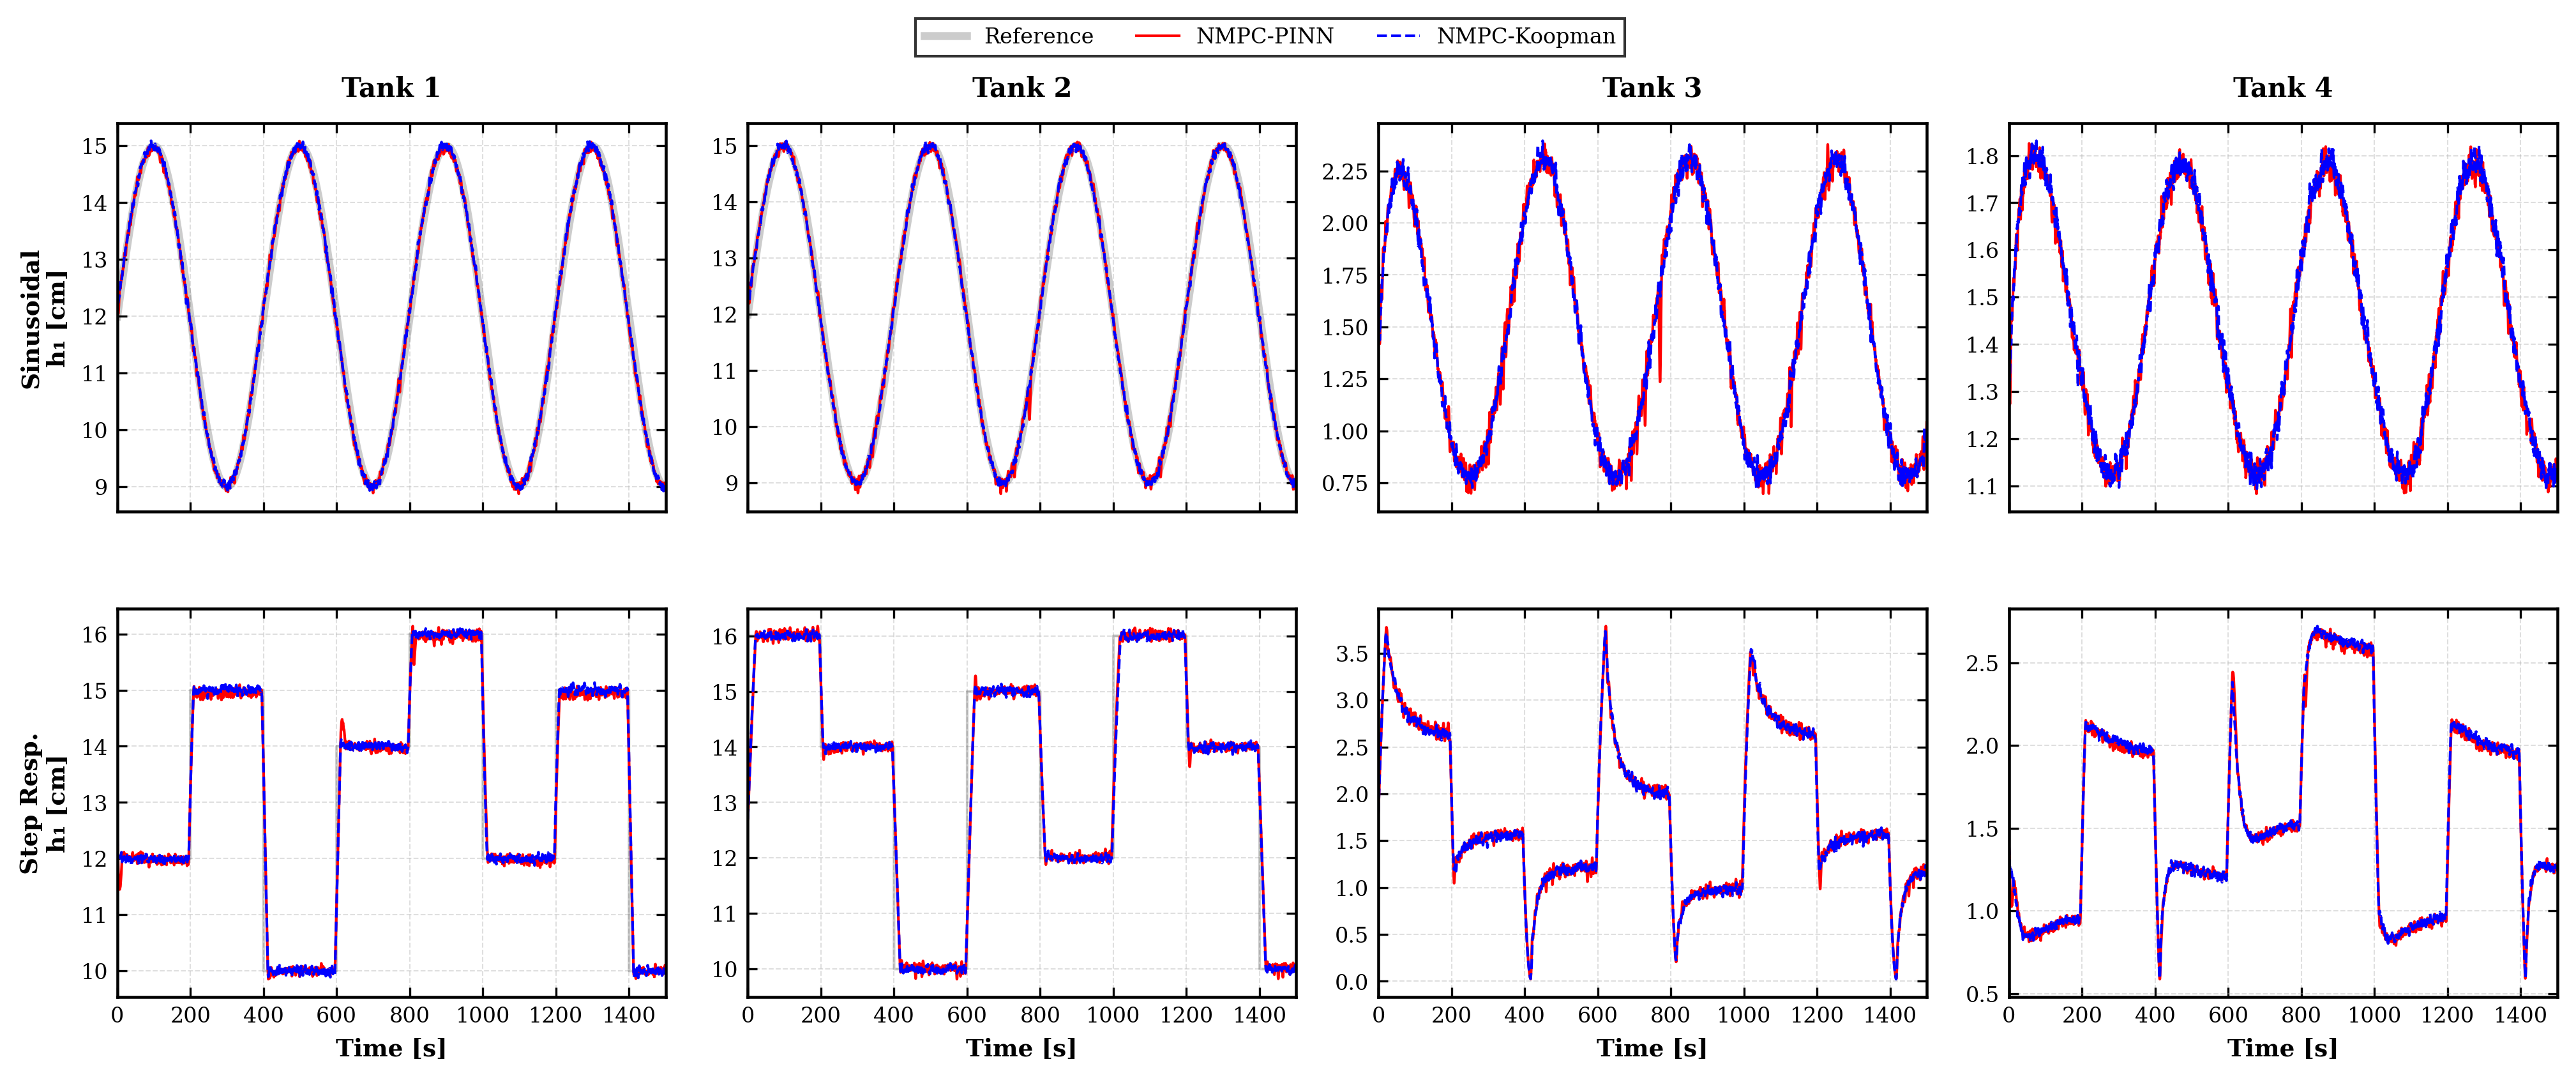

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. CARGA DE DATOS
# Asegúrate de que los archivos existan en tu directorio de trabajo
df_bilinear_s = pd.read_csv('control_lazo_cerrado_bilinear_sinusoidal.csv')
df_pinn_s = pd.read_csv('control_lazo_cerrado_PINN_sinusoidal.csv')
df_bilinear_c = pd.read_csv('control_lazo_cerrado_bilinear_cuadrada.csv')
df_pinn_c = pd.read_csv('control_lazo_cerrado_PINN_cuadrada.csv')

# 2. CONFIGURACIÓN ESTILO IEEE (CORREGIDO PARA EVITAR WARNINGS)
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    # Se añaden fuentes alternativas como 'DejaVu Serif' o 'Liberation Serif'
    # que son estándar en sistemas Linux y evitan el warning de 'font not found'.
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.linewidth": 1.1,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.0
})

# 2 filas (Escenarios) y 4 columnas (Tanques)
fig, axs = plt.subplots(2, 4, figsize=(14, 6), sharex=True, dpi=300)

config = [
    (0, 'Tank 1', 'h₁ [cm]', 'h1'),
    (1, 'Tank 2', 'h₂ [cm]', 'h2'),
    (2, 'Tank 3', 'h₃ [cm]', 'h3'),
    (3, 'Tank 4', 'h₄ [cm]', 'h4')
]

for col_idx, title, ylabel, h_id in config:
    # --- FILA 0: MIMO SINUSOIDAL ---
    ax0 = axs[0, col_idx]
    t_s = df_bilinear_s['Tiempo [s]']

    # Graficar referencia SOLO si es h1 o h2
    if h_id in ['h1', 'h2']:
        ax0.plot(t_s, df_bilinear_s[f'{h_id}_Ref [cm]'], color='black', alpha=0.2, linewidth=3, label='Reference')

    ax0.plot(t_s, df_pinn_s[f'{h_id}_Real [cm]'], color='red', linestyle='-', label='NMPC-PINN')
    ax0.plot(t_s, df_bilinear_s[f'{h_id}_Real [cm]'], color='blue', linestyle='--', label='NMPC-Koopman')
    ax0.set_title(title, fontsize=10, fontweight='bold', pad=10)

    # --- FILA 1: STEP RESPONSE (CUADRADA) ---
    ax1 = axs[1, col_idx]
    t_c = df_bilinear_c['Tiempo [s]']

    # Graficar referencia SOLO si es h1 o h2
    if h_id in ['h1', 'h2']:
        ax1.plot(t_c, df_bilinear_c[f'{h_id}_Ref [cm]'], color='black', alpha=0.2)

    ax1.plot(t_c, df_pinn_c[f'{h_id}_Real [cm]'], color='red', linestyle='-')
    ax1.plot(t_c, df_bilinear_c[f'{h_id}_Real [cm]'], color='blue', linestyle='--')

    for ax in [ax0, ax1]:
        ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
        ax.tick_params(direction='in', top=True, right=True)
        ax.set_xlim(0, 1500)

    if col_idx == 0:
        ax0.set_ylabel('Sinusoidal\n' + ylabel, fontweight='bold')
        ax1.set_ylabel('Step Resp.\n' + ylabel, fontweight='bold')

    ax1.set_xlabel('Time [s]', fontweight='bold')

# --- LEYENDA GLOBAL ---
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center',
           bbox_to_anchor=(0.5, 0.98),
           ncol=3, frameon=True, edgecolor='black', fancybox=False)

plt.subplots_adjust(hspace=0.25, wspace=0.15, top=0.88, bottom=0.12, left=0.07, right=0.98)

plt.savefig('combined_control_results_2x4.pdf', bbox_inches='tight')
plt.show()